# Two-pole bessel: the stimulus filter

The HEKA EPC-10 uses a second order Bessel filter in its "stimulus filter", which is applied to voltage steps to reduce capacitative transients.

Unlike the output filters, this filter is configured by settings [rise time](https://en.wikipedia.org/wiki/Rise_time) of either 20$\mu$s or 2$\mu$s.

Below, we (1) create a filter with these rise times, but then (2) show that the rise time in modern amplifiers no longer matches 20 or 2$\mu$s, (3) perform fits to find replacement values, and finally (4) compare with a 1-pole approximation.

## 1. Working out the rise time

We start by working out the filter's _step response_, i.e. the response to
\begin{align}
u(t) = \delta(t) && U(s) = \frac{1}{s}
\end{align}
for the system
\begin{align}
Y(s) = H(s)U(s) = \frac{3}{s(s^2 + 3s + 3)}
\end{align}

To solve this, we split into partial coefficients while keeping the second-order term together:

\begin{align}
Y(s) = \frac{3}{s(s^2 + 3s + 3)} 
     = \frac{A}{s} + \frac{B + Cs}{s^2 + 3s + 3}
\end{align}

\begin{align}
3 &= A(s^2 + 3s + 3) + Bs + Cs^2 \\
  &= (A + C)s^2 + (3A + B)s + 3A
\end{align}
\begin{align}
A = 1 && B = -3 && C = -1
\end{align}

\begin{align}
Y(s) = \frac{1}{s} + \frac{-3 - s}{s^2 + 3s + 3}
     = \frac{1}{s} - \frac{3 + s}{s^2 + 3s + 3}
\end{align}

To save time, we could also have [asked a website](https://www.wolframalpha.com/input?i=partial+fractions+3%2F%28s%28s%5E2+%2B+3s+%2B+3%29%29) or used [SymPy](https://docs.sympy.org/latest/modules/polys/reference.html#sympy.polys.partfrac.apart):

In [1]:
from sympy.polys.partfrac import apart
from sympy.abc import s

apart(3 / (s * (s**2 + 3 * s + 3)))

-(s + 3)/(s**2 + 3*s + 3) + 1/s

To get the inverse transform, we can write this in pole-zero form:
\begin{align}
Y(s) = \frac{1}{s} - \frac{3 + s}{(s + \sigma - i\omega)(s + \sigma + i\omega)},
&& \sigma = 3/2,
&& \omega = \sqrt{3}/2
\end{align}

This has the advantage that we can look up the standard solution, e.g. in Appendix A
\begin{align}
F(s) &= \frac{C_1 + C_2 s}{(s + \sigma - i\omega)(s + \sigma + i\omega)} \\
f(t) &= \left( \frac{C_1 - C_2\sigma}{\omega}e^{-\sigma t} \sin(\omega t) + C_2 e^{-\sigma t} \cos(\omega t) \right) \theta(t)
\end{align}

to find
\begin{align}
y(t) &= \theta(t) - \left( \frac{C_1 - C_2\sigma}{\omega}e^{-\sigma t} \sin(\omega t) + C_2 e^{-\sigma t} \cos(\omega t) \right) \theta(t) \\
&= \theta(t) \left[1 - \frac{3 - 3/2}{\sqrt{3}/2}e^{-3/2t} \sin(\sqrt{3}/2 t) + e^{-3/2 t} \cos(\sqrt{3}/2 t) \right] \\
&= \theta(t) \left[1 - (\sqrt{3} \sin(\sqrt{3}/2 t) + \cos(\sqrt{3}/2 t))e^{-3/2t} \right]
\end{align}

Let's plot it:

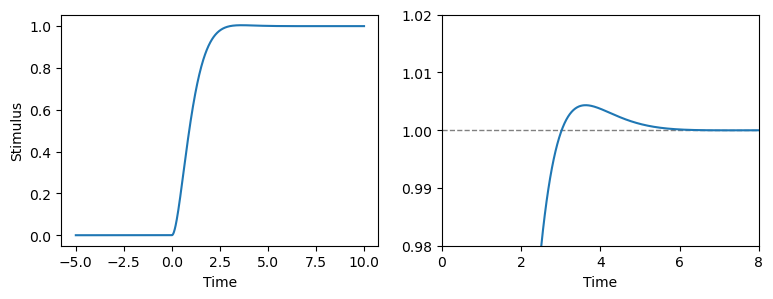

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(-5, 10, 1000)

def bessel2_step(t):
    theta = 1 * (t >= 0)
    s = np.sqrt(3)
    return theta * (1 - (s * np.sin(s/2*t) + np.cos(s/2*t)) * np.exp(-3/2*t))

y = bessel2_step(t)

fig = plt.figure(figsize=(9, 3))
fig.subplots_adjust(hspace=0.2)
ax = fig.add_subplot(1, 2, 1)
ax.update(dict(xlabel='Time', ylabel='Stimulus'))
ax.plot(t, y)
ax = fig.add_subplot(1, 2, 2)
ax.set_xlabel('Time')
ax.axhline(1, color='grey', ls='--', lw=1)
ax.plot(t, y)
ax.set_xlim(0, 8)
ax.set_ylim(0.98, 1.02)
plt.show()

This looks good! And on the right we can see the near lack of overshoot that makes Bessel filters popular.

We can use the equations above to work out the rise time, but it's probably not a lovely expression so we'll just do it numerically:

0.2999218750000007 0.10001114060500294
1.8783203124999999 0.8999978202201413


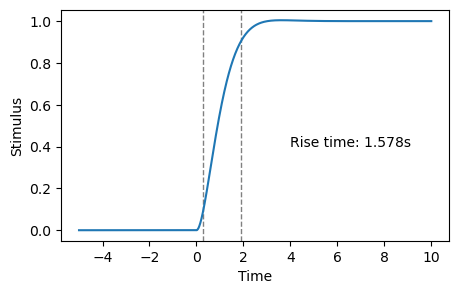

In [3]:
from scipy.optimize import fmin
t10 = fmin(lambda x: (bessel2_step(x) - 0.1)**2, 0.1, disp=False)[0]
t90 = fmin(lambda x: (bessel2_step(x) - 0.9)**2, 2, disp=False)[0]
print(t10, bessel2_step(t10))
print(t90, bessel2_step(t90))
fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot()
ax.update(dict(xlabel='Time', ylabel='Stimulus'))
ax.axvline(t10, color='grey', ls='--', lw=1)
ax.axvline(t90, color='grey', ls='--', lw=1)
ax.plot(t, y)
ax.text(4, 0.4, f'Rise time: {t90 - t10:.4}s')
plt.show()

To emulate a rise time of 20$\mu$s, we scale $t$:

Time, filter value
0.0038124999999999843 0.10029671636557969
0.0238125 0.8996055239892486


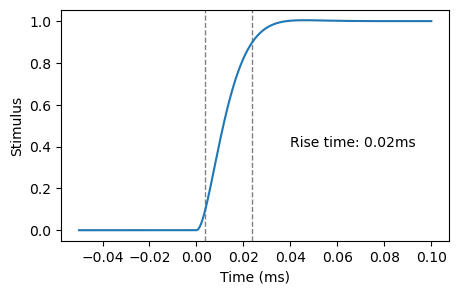

In [23]:
t = np.linspace(-0.05, 0.1, 1000)

def bessel2_step(t, x):
    theta = 1 * (t >= 0)
    s = np.sqrt(3)
    t = t / 2 * x
    return theta * (1 - (s * np.sin(s*t) + np.cos(s*t)) * np.exp(-3*t))

f = 78.8
y = bessel2_step(t, f)

t10 = fmin(lambda x: (bessel2_step(x, f) - 0.1)**2, 0.01, disp=False)[0]
t90 = fmin(lambda x: (bessel2_step(x, f) - 0.9)**2, 0.02, disp=False)[0]

print('Time, filter value')
print(t10, bessel2_step(t10, f))
print(t90, bessel2_step(t90, f))

fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot()
ax.update(dict(xlabel='Time (ms)', ylabel='Stimulus'))
ax.axvline(t10, color='grey', ls='--', lw=1)
ax.axvline(t90, color='grey', ls='--', lw=1)
ax.plot(t, y)
ax.text(0.04, 0.4, f'Rise time: {t90 - t10:.5}ms')
plt.show()

## 2. Comparing with measured values

The HEKA EPC-9 has a [paper describing its hardware](), which contains a nice block diagram (Fig 1).
This shows us that

1. The stimulus filter is applied to the command potential before any other additions (e.g. Cm and Rs compensation)
2. The "V monitor" is read directly from the stimulus filter output, again without any interference from other components.

As a result, we should be able to see the effects of the stimulus filter on a recorded "V monitor" signal.

Below is a recording made using an EPC-10:

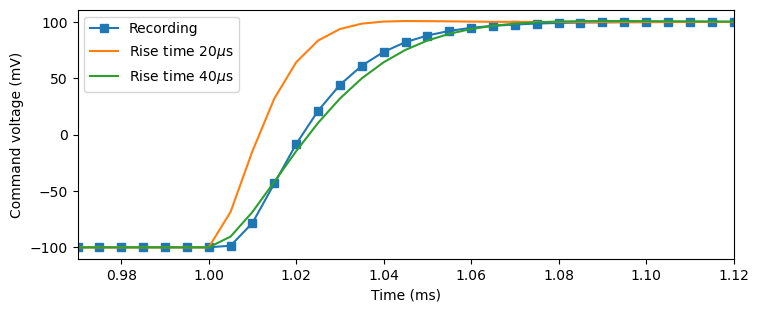

In [14]:
import myokit
d = myokit.DataLog.load('./res/stimulus-filter.zip')
d = d.npview()

fig = plt.figure(figsize=(8, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)
ax = fig.add_subplot()
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')

ax.plot(d.time(), d['v20us'], 's-', label='Recording')

t = d.time()
y = -100 + 200 * bessel2_step(t - 1, 78.8)
ax.plot(t, y, label=r'Rise time 20$\mu$s')
y = -100 + 200 * bessel2_step(t - 1, 78.8 / 2)
ax.plot(t, y, label=r'Rise time 40$\mu$s')

ax.legend()
ax.set_xlim(0.97, 1.12)
plt.show()

In [6]:
f = 40
t10 = fmin(lambda x: (bessel2_step(x, f) - 0.1)**2, 0.01, disp=False)[0]
t90 = fmin(lambda x: (bessel2_step(x, f) - 0.9)**2, 0.02, disp=False)[0]
assert abs(bessel2_step(t10, f) - 0.1) < 1e-2
assert abs(bessel2_step(t90, f) - 0.9) < 1e-2
print(t90 - t10)

0.03943750000000005


It seems the rise time is roughly twice what is advertised.

## 3. Fitting rise times

To fit the data, we start by writing the model in ODE form using Myokit, and comparing with recorded data for the 2$\mu$s and 20$\mu$s settings.

This means we need to specify a value for the filter's scaling factor $\alpha$.
For other filters, we've related this to cut-off frequency, but to stay closer to the amplifier settings, we'll try to relate it to rise time instead.
And to simplify this, we will use the equation for **first order** rise time:

\begin{align}
\alpha \approx \frac{1.3616}{\log 9} t_r
\end{align}


In [24]:
m = myokit.parse_model("""
[[model]]
filter.y1 = 0
filter.y2 = 0

[filter]
pace = 0 bind pace
time = 0 bind time
tr = 0.04 [ms] in [ms]
a2 = tr * 1.3616 / log(9)
    in [ms]
dot(y1) = 3 * (pace/a2^2 - y2/a2^2 - y1/a2)
dot(y2) = y1
""")

Next, we set up the same experiment we performed on a real amplifier, and compare the results **using our guesses of two times the given value**, and **using the first order rise time approximation**.

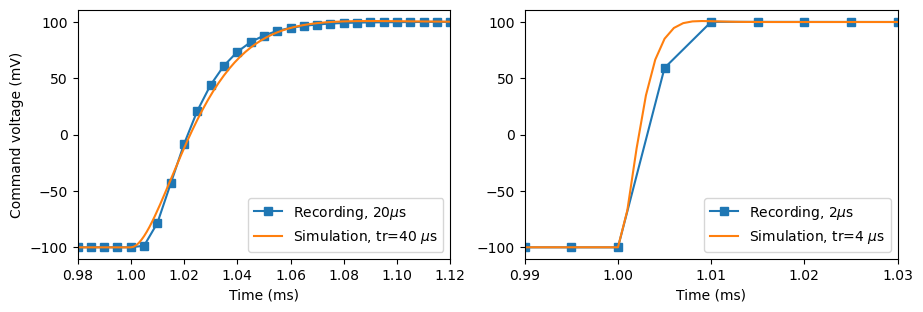

In [28]:
fig = plt.figure(figsize=(10, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)

ax = fig.add_subplot(1, 2, 1)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')
ax.plot(d0.time(), d0['v20us'], 's-', label=r'Recording, 20$\mu$s')
ax.plot(d1.time(), d1['filter.y2'], label=r'Simulation, tr=40 $\mu$s')
ax.legend()
ax.set_xlim(0.98, 1.12)

ax = fig.add_subplot(1, 2, 2)
ax.set_xlabel('Time (ms)')
ax.plot(d0.time(), d0['v2us'], 's-', label=r'Recording, 2$\mu$s')
ax.plot(d1.time(), d2['filter.y2'], label=r'Simulation, tr=4 $\mu$s')
ax.legend()
ax.set_xlim(0.99, 1.03)
plt.show()

This fits very well! 

But we can use an optimiser to find the best approximations:

In [29]:
from scipy.optimize import fmin

def error(tr):
    s.reset()
    s.set_constant('filter.tr', tr[0])
    d = s.run(2, log_times=d0.time())
    return np.sum((d0['v20us'] - d['filter.y2'])**2)

tr2slow = fmin(error, 0.04, disp=False)[0]
print(f'Rise time {tr2slow} ms')

s.set_constant('filter.tr', tr2slow)
s.reset()
s.pre(1)
d1 = s.run(2, log_interval=1e-3).npview()

Rise time 0.03838024902343749 ms


In [30]:
def error(tr):
    s.reset()
    s.set_constant('filter.tr', tr[0])
    d = s.run(2, log_times=d0.time())
    return np.sum((d0['v2us'] - d['filter.y2'])**2)

tr2fast = fmin(error, 0.004, disp=False)[0]
print(f'Rise time {tr2fast} ms')

s.set_constant('filter.tr', tr2fast)
s.reset()
s.pre(1)
d2 = s.run(2, log_interval=1e-3).npview()

Rise time 0.005369531250000004 ms


Summing up, in the two-pole formulation

**The 20$\mu$s setting is replicated by `tr=0.03838[ms]` or `tr=0.04[ms]`.**

**The 2$\mu$s setting is replicated by `tr=0.005369[ms]` or `tr=0.005[ms]`.**

## 4. A first order approximation

Finally, we approximate with a 1-pole filter, and perform the same fits.

In [31]:
m = myokit.parse_model("""
[[model]]
filter.y1 = 0
filter.y2 = 0
filter.y3 = 0

[filter]
pace = 0 bind pace
time = 0 bind time
tr = 0.04 [ms] in [ms]
# Second-order
a2 = tr * 1.3616 / log(9)
    in [ms]
dot(y1) = 3 * (pace/a2^2 - y2/a2^2 - y1/a2)
dot(y2) = y1
# First-order
a1 = tr / log(9)
    in [ms]
dot(y3) = (pace - y3) / a1
""")

p = myokit.Protocol()
p.add_step(level=-100, duration=1)
p.add_step(level=100, duration=10)

s = myokit.Simulation(m, p)
s.pre(1)
d1 = s.run(2, log_interval=1e-3).npview()

s.reset()
s.set_constant('filter.tr', 0.004)
s.pre(1)
d2 = s.run(2, log_interval=1e-3).npview()

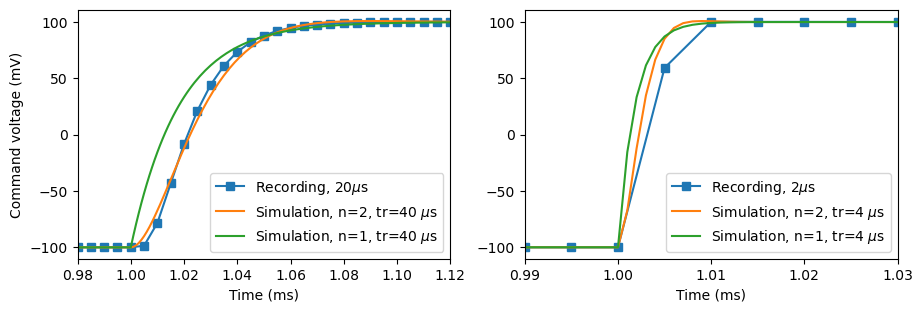

In [32]:
fig = plt.figure(figsize=(10, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)

ax = fig.add_subplot(1, 2, 1)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')
ax.plot(d0.time(), d0['v20us'], 's-', label=r'Recording, 20$\mu$s')
ax.plot(d1.time(), d1['filter.y2'], label=r'Simulation, n=2, tr=40 $\mu$s')
ax.plot(d1.time(), d1['filter.y3'], label=r'Simulation, n=1, tr=40 $\mu$s')
ax.legend()
ax.set_xlim(0.98, 1.12)

ax = fig.add_subplot(1, 2, 2)
ax.set_xlabel('Time (ms)')
ax.plot(d0.time(), d0['v2us'], 's-', label=r'Recording, 2$\mu$s')
ax.plot(d1.time(), d2['filter.y2'], label=r'Simulation, n=2, tr=4 $\mu$s')
ax.plot(d1.time(), d2['filter.y3'], label=r'Simulation, n=1, tr=4 $\mu$s')
ax.legend()
ax.set_xlim(0.99, 1.03)
plt.show()

This is not far off at all, and any discrepancies only last for 0.1ms. Compared to e.g. fast-capacitance compensation, it is unlikely that approximating as first order will cause any problems.

As above, we'll use an optimiser to find time constants that match best:

In [33]:
def error(tr):
    s.reset()
    s.set_constant('filter.tr', tr[0])
    d = s.run(2, log_times=d0.time())
    return np.sum((d0['v20us'] - d['filter.y3'])**2)

tr1slow = fmin(error, 0.04, disp=False)[0]
print(f'Rise time {tr1slow} ms')
print(f'Time constant {tr1slow / np.log(9)} ms')

s.set_constant('filter.tr', tr1slow)
s.reset()
s.pre(1)
d3 = s.run(2, log_interval=1e-3).npview()

Rise time 0.05562500000000001 ms
Time constant 0.025316028490558917 ms


In [34]:
def error(tr):
    s.reset()
    s.set_constant('filter.tr', tr[0])
    d = s.run(2, log_times=d0.time())
    return np.sum((d0['v2us'] - d['filter.y3'])**2)

tr1fast = fmin(error, 0.004, disp=False)[0]
print(f'Rise time {tr1fast} ms')
print(f'Time constant {tr1fast / np.log(9)} ms')

s.set_constant('filter.tr', tr1fast)
s.reset()
s.pre(1)
d4 = s.run(2, log_interval=1e-3).npview()

Rise time 0.006590625000000008 ms
Time constant 0.0029995227014937534 ms


Summing up, in the one-pole approximation

**The 20$\mu$s setting is replicated by `tau=0.025[ms]`.**

**The 2$\mu$s setting is replicated by `tr=0.003[ms]`.**